In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles

n --> número de registro que tenemos en nuestro datos
p --> cuantas características tenemos en cada uno de nuetros datos

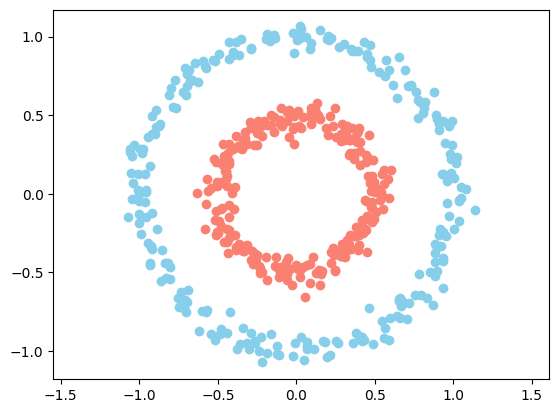

In [2]:
# CREAR DATASET

n = 500
p = 2

# 1. Primero creamos el dataset (Y nace siendo 1D)
X, Y = make_circles(n_samples=n, factor=0.5, noise=0.05)

# 2. LUEGO le añadimos la nueva dimensión (Y se convierte en 2D)
Y = Y[:, np.newaxis]

plt.scatter(X[Y[:, 0] == 0, 0], X[Y[:, 0] == 0, 1], c="skyblue")
plt.scatter(X[Y[:, 0] == 1, 0], X[Y[:, 0] == 1, 1], c="salmon")
plt.axis('equal')
plt.show()

In [3]:
class neural_layer():
  # Nota: esta clase solo GUARDA los parámetros de la capa (pesos W y sesgo b)
  # y su función de activación. El cálculo del forward pass (multiplicar,
  # sumar y activar) lo haremos fuera, en la función train(), para poder
  # controlar todo el flujo de datos entre capas en un solo sitio.

  def __init__(self, n_conn, n_neur, act_f):
    self.act_f = act_f

    self.b = np.random.rand(1, n_neur) *2 - 1
    self.W = np.random.rand(n_conn, n_neur) *2 - 1


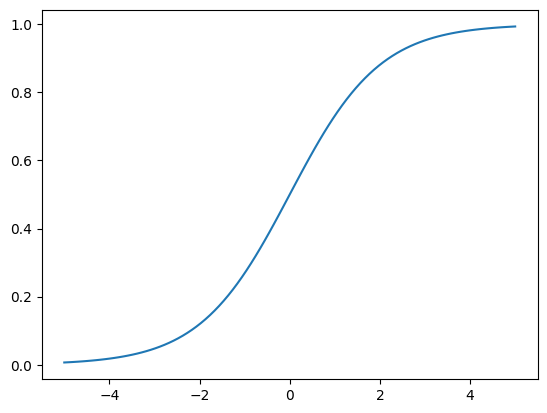

In [4]:
#FUNCIONES DE ACTIVACION

sigm = (lambda x: 1 / (1 + np.e **(-x)),
        lambda x: x* (1 - x))
relu = lambda x: np.maximum(0,x)

_x = np.linspace(-5, 5, 100)
plt.plot(_x,sigm[0](_x))


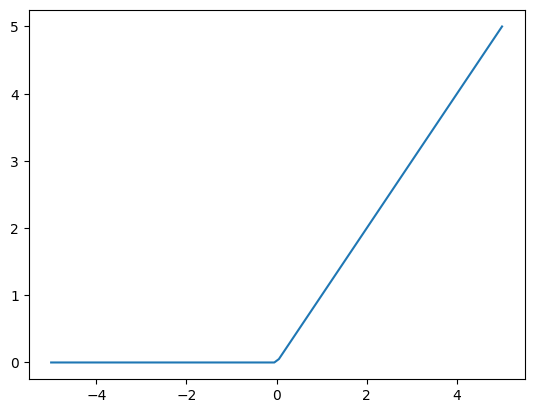

In [5]:
plt.plot(_x, relu(_x))

Empezamos a crear nuestra red neuronal

In [6]:
# Ejemplo manual de cómo se crearían un par de capas sueltas.
# OJO: l0 y l1 son solo demostrativas, no se usan en el entrenamiento real;
# más abajo automatizamos esto con la función create_nn().
l0 = neural_layer(p, 4, sigm) # crea un objeto de tipo capa donde el número de conexiones de entrada = p
                              #neuronas = 4 f_act = sigm
l1 = neural_layer(4, 8, sigm) # ahora la entrada son 4 porque viene de la anterior capa
#...


Vamos a hacer una función que se va a encargar de crear nuestra red neuronal

---



In [7]:
#variable topology = topología de la red (define el número de neuronas que tiene la red)

 # número de neuronas por capa (1 porque queremos una salida con un número binario)

def create_nn(topology, act_f):
  nn = []
  for l, layer in enumerate(topology[:-1]):# te da tanto el índice como el vector del objeto que estas recorriendo y que recorra todo hasta el último
    nn.append(neural_layer(topology[l], topology[l+1], act_f))

  return nn


In [8]:
print("con esto tendriamos creado toda la estructura de datos que soporta nuestra red neuronal")

con esto tendriamos creado toda la estructura de datos que soporta nuestra red neuronal


A partir de aquí empezamos a poder entrenar a la red neuronal

In [9]:
# definir el código que se va a encargar de entrenar a nuestra red neuronal
topology = [p, 4 , 8, 1]

neural_net = create_nn(topology, sigm)

l2_cost = (lambda Yp, Yr: np.mean((Yp -Yr) **2), #error cuadrático medio
          lambda Yp, Yr: (Yp - Yr)) # derivada de la función

def train(neural_net, X, Y, l2_cost, lr=0.5, train=True):

    # Iniciamos la "memoria" de la red.
    # El primer elemento contiene los datos de entrada originales (X).
    out = [(None, X)]

    # ==========================================
    # 1. FORWARD PASS (Pasar la información hacia adelante)
    # ==========================================
    for l, layer in enumerate(neural_net):

        # Calculamos la suma ponderada (z):
        # Multiplicamos la activación de la capa anterior por los pesos y sumamos el sesgo
        z = out[-1][1] @ neural_net[l].W + neural_net[l].b

        # Pasamos 'z' por la función de activación (ej. Sigmoide) usando el índice [0]
        a = neural_net[l].act_f[0](z)

        # Guardamos los resultados (z, a) en la memoria para usarlos en el Backpropagation
        out.append((z, a))

    # Si queremos que la red aprenda (train=True), ejecutamos la corrección de errores
    if train:

        # ==========================================
        # 2. BACKWARD PASS (Propagar el error hacia atrás)
        # ==========================================
        deltas = [] # Lista para guardar el grado de error (loss) de cada capa

        # Recorremos la red desde la última capa hasta la primera
        for l in reversed(range(0, len(neural_net))):

            # Recuperamos 'z' y 'a' de la capa actual
            z = out[l+1][0]
            a = out[l+1][1]

            # CASO A: Si estamos en la ÚLTIMA capa
            if l == len(neural_net) - 1:
                # El error se calcula comparando nuestra predicción (a) directamente con la realidad (Y)
                deltas.insert(0, l2_cost[1](a, Y) * neural_net[l].act_f[1](a))

            # CASO B: Si estamos en una capa OCULTA
            else:
                # El error se calcula multiplicando el error de la capa siguiente (deltas[0])
                # por los pesos transpuestos de esa capa siguiente (_W.T)
                deltas.insert(0, deltas[0] @ _W.T * neural_net[l].act_f[1](a))

            # Guardamos los pesos actuales de esta capa para que la capa anterior pueda usarlos en su "CASO B"
            _W = neural_net[l].W

            # ==========================================
            # 3. GRADIENT DESCENT (Actualizar los parámetros)
            # ==========================================

            # Ajustamos el sesgo (b) restándole la media del error multiplicada por el learning rate (lr)
            neural_net[l].b = neural_net[l].b - np.mean(deltas[0], axis=0, keepdims=True) * lr

            # Ajustamos los pesos (W) multiplicando la activación de la capa anterior por el error actual
            neural_net[l].W = neural_net[l].W - out[l][1].T @ deltas[0] * lr

    # Al final, devolvemos la última predicción de la red (la activación de la última capa)
    return out[-1][1]

# Ejecutamos la función por primera vez
train(neural_net, X, Y, l2_cost, 0.5)

array([[0.48345933],
       [0.47929414],
       [0.47778523],
       [0.48674472],
       [0.4768091 ],
       [0.47717534],
       [0.48550005],
       [0.47175998],
       [0.49043554],
       [0.48676035],
       [0.47717743],
       [0.47944648],
       [0.48718688],
       [0.48226585],
       [0.48930753],
       [0.4735731 ],
       [0.48631151],
       [0.49315874],
       [0.48143813],
       [0.47762535],
       [0.47729952],
       [0.48157867],
       [0.4793784 ],
       [0.47189786],
       [0.47654051],
       [0.48459282],
       [0.48371516],
       [0.47612216],
       [0.47737937],
       [0.47854034],
       [0.49187213],
       [0.47571067],
       [0.49100854],
       [0.47300304],
       [0.48194418],
       [0.47364694],
       [0.47292583],
       [0.48040962],
       [0.48639347],
       [0.47637651],
       [0.48716081],
       [0.48905596],
       [0.47596061],
       [0.4808459 ],
       [0.48109618],
       [0.48474315],
       [0.47188846],
       [0.476

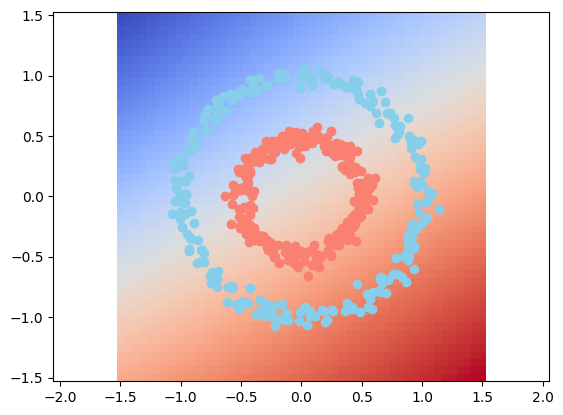

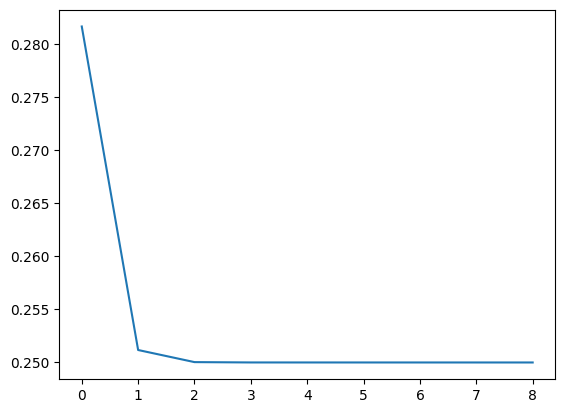

KeyboardInterrupt: 

In [10]:
import time
from IPython.display import clear_output

# 1. Creamos la red neuronal desde cero (con la topología y la función de activación)
neural_n = create_nn(topology, sigm)

# 2. Creamos una lista para ir guardando cómo el error baja con el tiempo
loss = []

# 3. EL BUCLE DE ENTRENAMIENTO (Epochs)
# Entrenaremos a la red 1000 veces seguidas
for i in range(1000):

  # Entrenemos a la red!
  # Ejecutamos el Forward y Backward pass. pY guarda las predicciones de esta vuelta.
  # Nota: learning rate (lr) bajito (0.001) para que aprenda pasito a pasito sin descontrolarse.
  pY = train(neural_n, X, Y, l2_cost, lr=0.001)

  # 4. ANIMACIÓN Y MÉTRICAS (Solo cada 25 iteraciones para no saturar el ordenador)
  if i % 25 == 0:

    # Calculamos el error actual usando la función de coste [0] y lo guardamos
    loss.append(l2_cost[0](pY, Y))
    print(f"Epoch {i} - Loss: {loss[-1]:.4f}")

    # 5. CREACIÓN DE LA MALLA DE PREDICCIÓN (Frontera de decisión)
    res = 50 # Resolución de la malla (50x50 puntos)

    # Creamos un eje X y un eje Y imaginarios que van de -1.5 a 1.5
    _x0 = np.linspace(-1.5, 1.5, res)
    _x1 = np.linspace(-1.5, 1.5, res)

    # Creamos una matriz vacía de 50x50 para guardar las predicciones de cada puntito
    _Y = np.zeros((res, res))

    # Recorremos cada puntito imaginario de la pantalla
    for i0, x0 in enumerate(_x0):
      for i1, x1 in enumerate(_x1):
        # ¡AQUÍ USAMOS train=False!
        # Le pedimos a la red que prediga el color de ese puntito sin modificar sus pesos
        _Y[i0, i1] = train(neural_n, np.array([[x0, x1]]), Y, l2_cost, train=False)[0][0]

    # 6. DIBUJAMOS TODO
    # Dibujamos el fondo difuminado (Rojo vs Azul) basado en las predicciones
    plt.pcolormesh(_x0, _x1, _Y, cmap="coolwarm")
    plt.axis("equal")

    # Dibujamos los puntos reales del dataset por encima para comparar
    plt.scatter(X[Y[:,0] == 0, 0], X[Y[:,0] == 0, 1], c="skyblue")
    plt.scatter(X[Y[:,0] == 1, 0], X[Y[:,0] == 1, 1], c="salmon")

    # 7. MAGIA DE LA ANIMACIÓN
    # Borra el gráfico anterior antes de dibujar el nuevo (crea efecto de vídeo)
    clear_output(wait=True)
    plt.show() # Muestra cómo va la frontera de decisión

    # Dibuja la gráfica del error (debería ir cayendo en picado como un tobogán)
    plt.plot(range(len(loss)), loss)
    plt.show()

    # Congela la pantalla medio segundo para que el ojo humano pueda ver el fotograma
    time.sleep(0.5)
